In [127]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


def moving_average(values, window=50):
    if len(values) < window:
        return values
    out, running = [], 0.0
    for i, v in enumerate(values):
        running += v
        if i >= window:
            running -= values[i - window]
        if i >= window - 1:
            out.append(running / window)
    return out


def make_gaussian_datasets(d, n_train, n_test, rho, device, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    m = d // 2
    L = np.linalg.cholesky(np.array([[1, rho], [rho, 1]], dtype=np.float32))

    def p(n):
        z = np.random.randn(n, m, 2).astype(np.float32)
        return torch.tensor((z @ L.T).reshape(n, d), dtype=torch.float32, device=device)

    def q(n):
        return torch.tensor(np.random.randn(n, d).astype(np.float32), dtype=torch.float32, device=device)

    p_train, q_train = p(n_train), q(n_train)
    p_test, q_test = p(n_test), q(n_test)

    print("shapes:", p_train.shape, q_train.shape, p_test.shape, q_test.shape)
    return p_train, q_train, p_test, q_test


class QuadraticBridge(nn.Module):
    def __init__(self, dim, num_bridges=1):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_bridges, dim, dim) * 1e-3)
        self.b = nn.Parameter(torch.zeros(num_bridges))

    def forward(self, x, k=0):
        Wk = 0.5 * (self.W[k] + self.W[k].transpose(-1, -2))  # symmetric
        return torch.einsum("bi,ij,bj->b", x, Wk, x) + self.b[k]


def train_quadratic_mi_estimator(
    p_train,
    q_train,
    p_test,
    rho,
    device,
    steps=1000,
    batch_size=256,
    k=0,
    num_bridges=1,
    lr=1e-2,
    eval_every=50,
):
    dim = p_train.shape[1]
    true_mi = -0.5 * (dim // 2) * math.log(1 - rho**2)
    print("True MI / KL value =", true_mi)

    model = QuadraticBridge(dim, num_bridges).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    loss_steps, loss_history, mi_steps, mi_history = [], [], [], []
    half = batch_size // 2

    for step in range(1, steps + 1):
        ip = torch.randint(0, len(p_train), (half,), device=device)
        iq = torch.randint(0, len(q_train), (half,), device=device)
        xp, xq = p_train[ip], q_train[iq]

        sp = model(xp, k)
        sq = model(xq, k)

        scores = torch.cat([sp, sq], dim=0)
        labels = torch.cat([torch.ones_like(sp), torch.zeros_like(sq)], dim=0)

        loss = loss_fn(scores, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_steps.append(step)
        loss_history.append(loss.item())

        if step == 1 or step % eval_every == 0:
            with torch.no_grad():
                mi_est = model(p_test, k).mean().item()
            mi_steps.append(step)
            mi_history.append(mi_est)
            print(
                f"step {step:5d} | "
                f"loss = {loss.item():.6f} | "
                f"MI estimate = {mi_est:.6f} | "
                f"true = {true_mi:.6f}"
            )

    return {
        "model": model,
        "true_mi": true_mi,
        "loss_steps": loss_steps,
        "loss_history": loss_history,
        "mi_steps": mi_steps,
        "mi_history": mi_history,
        "W_sym": 0.5 * (model.W[k].detach() + model.W[k].detach().T),
        "b": model.b[k].detach(),
        "rho": rho,
        "dim": dim,
        "device": device,
    }


def plot_training_results(results, smooth_window=50):
    loss_steps = results["loss_steps"]
    loss_history = results["loss_history"]
    mi_steps = results["mi_steps"]
    mi_history = results["mi_history"]
    true_mi = results["true_mi"]

    loss_smooth = moving_average(loss_history, window=smooth_window)
    loss_smooth_steps = loss_steps[smooth_window - 1:] if len(loss_history) >= smooth_window else loss_steps

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(loss_steps, loss_history, alpha=0.35, label="Raw loss")
    if len(loss_smooth) > 0:
        axes[0].plot(
            loss_smooth_steps,
            loss_smooth,
            linewidth=2,
            label=f"Smoothed loss ({smooth_window}-step MA)",
        )
    axes[0].set_title("Training loss over time")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("BCE loss")
    axes[0].legend()

    axes[1].plot(mi_steps, mi_history, marker="o", label="Estimated MI")
    axes[1].axhline(true_mi, color="red", linestyle="--", label=f"True value = {true_mi:.4f}")
    axes[1].set_title("MI estimate over time")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("E_p[s(x)]")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def run_experiment(
    d,
    n_train,
    n_test,
    rho,
    device,
    steps=1000,
    batch_size=256,
    lr=1e-2,
    eval_every=50,
    k=0,
    num_bridges=1,
    seed=None,
    plot=True,
    smooth_window=50,
):
    p_train, q_train, p_test, q_test = make_gaussian_datasets(
        d=d, n_train=n_train, n_test=n_test, rho=rho, device=device, seed=seed
    )

    results = train_quadratic_mi_estimator(
        p_train=p_train,
        q_train=q_train,
        p_test=p_test,
        rho=rho,
        device=device,
        steps=steps,
        batch_size=batch_size,
        k=k,
        num_bridges=num_bridges,
        lr=lr,
        eval_every=eval_every,
    )

    results["p_train"] = p_train
    results["q_train"] = q_train
    results["p_test"] = p_test
    results["q_test"] = q_test

    if plot:
        plot_training_results(results, smooth_window=smooth_window)

    return results

shapes: torch.Size([10000, 20]) torch.Size([10000, 20]) torch.Size([2000, 20]) torch.Size([2000, 20])
True MI / KL value = 5.1082562376599085
step     1 | loss = 0.692904 | MI estimate = 0.155211 | true = 5.108256
step    50 | loss = 0.208364 | MI estimate = 2.414727 | true = 5.108256
step   100 | loss = 0.149489 | MI estimate = 3.017678 | true = 5.108256
step   150 | loss = 0.133703 | MI estimate = 3.320744 | true = 5.108256
step   200 | loss = 0.104664 | MI estimate = 3.540466 | true = 5.108256
step   250 | loss = 0.128439 | MI estimate = 3.791542 | true = 5.108256
step   300 | loss = 0.122455 | MI estimate = 3.814145 | true = 5.108256
step   350 | loss = 0.152181 | MI estimate = 4.313425 | true = 5.108256
step   400 | loss = 0.122225 | MI estimate = 3.921825 | true = 5.108256
step   450 | loss = 0.072066 | MI estimate = 4.540338 | true = 5.108256
step   500 | loss = 0.130167 | MI estimate = 4.420828 | true = 5.108256
step   550 | loss = 0.110706 | MI estimate = 4.773469 | true = 5.1

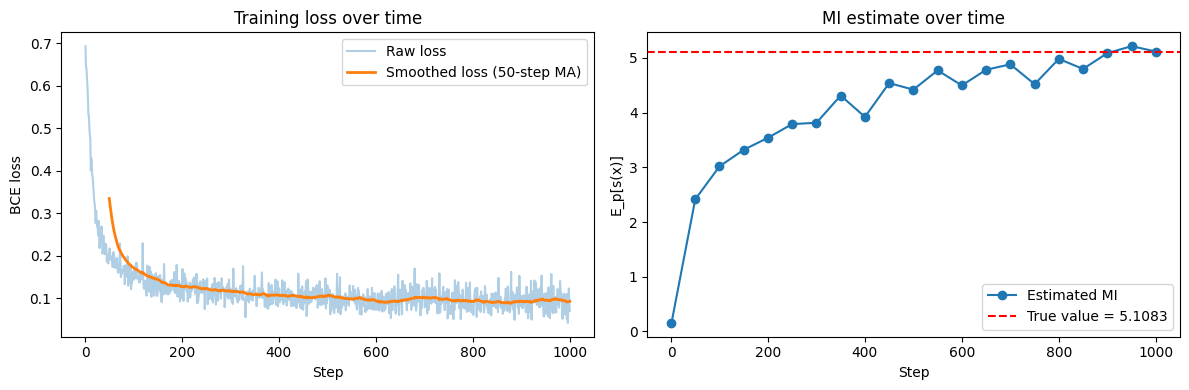

In [128]:
device = "cuda" if torch.cuda.is_available() else "cpu"

results = run_experiment(
    d=20,
    n_train=10000,
    n_test=2000,
    rho=0.8,
    device=device,
    steps=1000,
    batch_size=256,
    lr=1e-2,
    eval_every=50,
    seed=0,
    plot=True,
)

### Bregman TRE

In [103]:
# toy problem: 2D correlated Gaussian vs 2D standard Gaussian
num_dims = 40
rho = 0.8

n_train = 20000
n_test = 10000

steps = 3000
batch_size = 1024
lr = 5e-6

true_mi = -(num_dims / 4.0) * math.log(1 - rho**2)
print("true MI =", true_mi)


true MI = 10.216512475319817


In [104]:
# sample from p: correlated Gaussian in num_dims dimensions
# built from independent 2D blocks with covariance [[1, rho], [rho, 1]]

n_blocks = num_dims // 2

L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]], dtype=np.float32))

z_train = np.random.randn(n_train, n_blocks, 2).astype(np.float32)
p_train = (z_train @ L.T).reshape(n_train, num_dims).astype(np.float32)

z_test = np.random.randn(n_test, n_blocks, 2).astype(np.float32)
p_test = (z_test @ L.T).reshape(n_test, num_dims).astype(np.float32)

# sample from q: standard Gaussian in num_dims dimensions
q_train = np.random.randn(n_train, num_dims).astype(np.float32)
q_test = np.random.randn(n_test, num_dims).astype(np.float32)

# torch tensors
p_train = torch.tensor(p_train, dtype=torch.float32, device=device)
q_train = torch.tensor(q_train, dtype=torch.float32, device=device)
p_test = torch.tensor(p_test, dtype=torch.float32, device=device)
q_test = torch.tensor(q_test, dtype=torch.float32, device=device)

print(p_train.shape, q_train.shape, p_test.shape, q_test.shape)

torch.Size([20000, 40]) torch.Size([20000, 40]) torch.Size([10000, 40]) torch.Size([10000, 40])


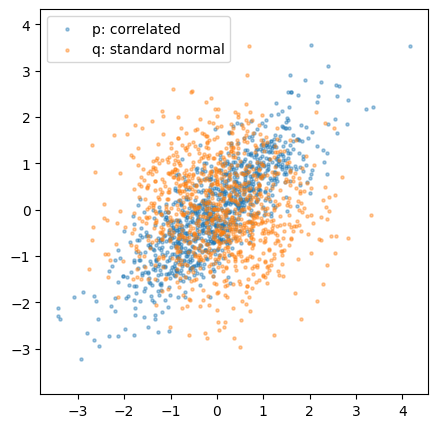

In [105]:
# quick picture of the two distributions
plt.figure(figsize=(5, 5))
plt.scatter(p_train[:1000, 0].cpu(), p_train[:1000, 1].cpu(), s=5, alpha=0.4, label="p: correlated")
plt.scatter(q_train[:1000, 0].cpu(), q_train[:1000, 1].cpu(), s=5, alpha=0.4, label="q: standard normal")
plt.legend()
plt.axis("equal")
plt.show()


In [106]:
import torch
import torch.nn as nn

# quadratic ratio model: s(x) = x^T W x + b
# here s(x) is interpreted as the log-ratio:
#     s(x) = log r(x)
# so the ratio itself is
#     r(x) = exp(s(x))

W = nn.Parameter(1e-3 * torch.randn(num_dims, num_dims, device=device))
b = nn.Parameter(torch.zeros(1, device=device))

optimizer = torch.optim.Adam([W, b], lr=lr)


class BregmanRatioLoss(nn.Module):
    """
    Bregman loss for density-ratio estimation when the model outputs log-ratio scores.

    If:
        score = log r(x),

    then:
        r(x) = exp(score),

    and the loss is:
        0.5 * E_q[r(x)^2] - E_p[r(x)]

    Therefore, in terms of scores:
        0.5 * E_q[exp(scores_q)^2] - E_p[exp(scores_p)]
    """

    def __init__(self):
        super().__init__()

    def forward(self, scores_p, scores_q):
        # Convert log-ratio scores into ratio estimates
        r_p = torch.exp(scores_p)
        r_q = torch.exp(scores_q)

        # Bregman ratio loss:
        #   0.5 * E_q[r^2] - E_p[r]
        return 0.5 * torch.mean(r_q ** 2) - torch.mean(r_p)


loss_fn = BregmanRatioLoss()


In [107]:
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ------------------------------------------------------------
# True value for your Gaussian setup
# ------------------------------------------------------------
# num_dims = total dimension = 2 * (# of 2x2 blocks)
# rho = off-diagonal correlation in each 2x2 block
rho = 0.8
num_blocks = num_dims // 2

# True E_p[ log p(x)/q(x) ] = KL(p || q)
# For this block-diagonal Gaussian vs standard normal:
# true_mi = -(num_blocks / 2) * log(1 - rho^2)
true_mi = -0.5 * num_blocks * math.log(1 - rho**2)

print("True MI / KL value =", true_mi)

# ------------------------------------------------------------
# History containers for plotting
# ------------------------------------------------------------
loss_steps = []      # training steps for loss
loss_history = []    # loss values

mi_steps = []        # training steps where MI is evaluated
mi_history = []      # estimated MI values on p_test

# Optional: evaluate every N steps for plotting
eval_every = 50

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
for step in range(1, steps + 1):
    # Randomly choose indices for a minibatch from p and q
    ip = torch.randint(0, len(p_train), (batch_size // 2,), device=device)
    iq = torch.randint(0, len(q_train), (batch_size // 2,), device=device)

    # Gather minibatches
    xp = p_train[ip]
    xq = q_train[iq]

    # Force the quadratic matrix to be symmetric
    # since x^T W x depends only on the symmetric part
    Ws = 0.5 * (W + W.T)

    # Score p samples: s(x) = x^T Ws x + b
    sp = torch.einsum("bi,ij,bj->b", xp, Ws, xp) + b

    # Score q samples
    sq = torch.einsum("bi,ij,bj->b", xq, Ws, xq) + b

    # Combine scores into one vector
    scores = torch.cat([sp, sq], dim=0)

    # Create binary labels: p -> 1, q -> 0
    labels = torch.cat([
        torch.ones_like(sp),
        torch.zeros_like(sq),
    ], dim=0)

    # Logistic classification loss
    loss = loss_fn(scores, labels)

    # Gradient step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Save loss every step
    loss_steps.append(step)
    loss_history.append(float(loss.item()))

    # Evaluate MI estimate every eval_every steps (and at step 1)
    if step % eval_every == 0 or step == 1:
        with torch.no_grad():
            Ws_eval = 0.5 * (W + W.T)

            # Evaluate score on held-out p_test samples
            s_test = torch.einsum("bi,ij,bj->b", p_test, Ws_eval, p_test) + b

            # Estimated E_p[log p/q]
            mi_est = s_test.mean().item()

        mi_steps.append(step)
        mi_history.append(mi_est)

        print(
            f"step {step:5d} | "
            f"loss = {float(loss.item()):.6f} | "
            f"MI estimate = {mi_est:.6f} | "
            f"true = {true_mi:.6f}"
        )

True MI / KL value = 10.216512475319817
step     1 | loss = 1.100908 | MI estimate = -0.002902 | true = 10.216512
step    50 | loss = 1.084959 | MI estimate = 0.014822 | true = 10.216512
step   100 | loss = 1.068048 | MI estimate = 0.033035 | true = 10.216512
step   150 | loss = 1.054613 | MI estimate = 0.051384 | true = 10.216512
step   200 | loss = 1.040584 | MI estimate = 0.069926 | true = 10.216512
step   250 | loss = 1.021584 | MI estimate = 0.088655 | true = 10.216512
step   300 | loss = 1.007670 | MI estimate = 0.107509 | true = 10.216512
step   350 | loss = 0.986156 | MI estimate = 0.126505 | true = 10.216512
step   400 | loss = 0.970254 | MI estimate = 0.145651 | true = 10.216512
step   450 | loss = 0.953723 | MI estimate = 0.165053 | true = 10.216512
step   500 | loss = 0.937139 | MI estimate = 0.184575 | true = 10.216512
step   550 | loss = 0.918308 | MI estimate = 0.204254 | true = 10.216512
step   600 | loss = 0.890363 | MI estimate = 0.224042 | true = 10.216512
step   650

KeyboardInterrupt: 

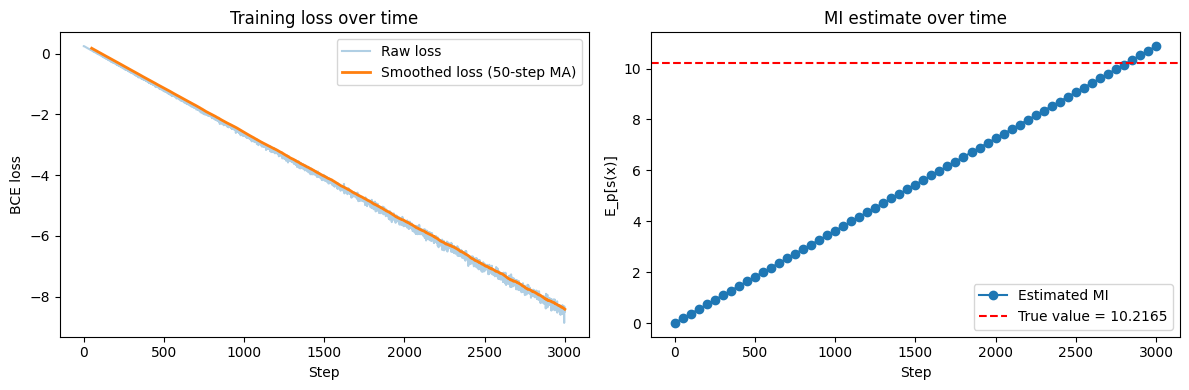

In [92]:
# ------------------------------------------------------------
# Optional: smooth the loss a little for easier viewing
# ------------------------------------------------------------
def moving_average(values, window=50):
    if len(values) < window:
        return values
    out = []
    running = 0.0
    for i, v in enumerate(values):
        running += v
        if i >= window:
            running -= values[i - window]
        if i >= window - 1:
            out.append(running / window)
    return out

smooth_window = 50
loss_smooth = moving_average(loss_history, window=smooth_window)
loss_smooth_steps = loss_steps[smooth_window - 1:] if len(loss_history) >= smooth_window else loss_steps

# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- Plot 1: training loss ----
axes[0].plot(loss_steps, loss_history, alpha=0.35, label="Raw loss")
if len(loss_smooth) > 0:
    axes[0].plot(loss_smooth_steps, loss_smooth, linewidth=2, label=f"Smoothed loss ({smooth_window}-step MA)")
axes[0].set_title("Training loss over time")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

# ---- Plot 2: MI estimate vs true value ----
axes[1].plot(mi_steps, mi_history, marker="o", label="Estimated MI")
axes[1].axhline(true_mi, color="red", linestyle="--", label=f"True value = {true_mi:.4f}")
axes[1].set_title("MI estimate over time")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("E_p[s(x)]")
axes[1].legend()

plt.tight_layout()
plt.show()

In [65]:
# final MI estimate
with torch.no_grad():
    Ws = 0.5 * (W + W.T)
    s_test = torch.einsum("bi,ij,bj->b", p_test, Ws, p_test) + b
    mi_est = s_test.mean().item()

print("estimated MI =", mi_est)
print("true MI      =", true_mi)
print("error        =", mi_est - true_mi)

estimated MI = 5.506528854370117
true MI      = 10.216512475319817
error        = -4.7099836209497


In [66]:
# inspect learned quadratic parameters
print("learned symmetric W =")
print((0.5 * (W + W.T)).detach().cpu().numpy())

print("learned b =")
print(b.detach().cpu().numpy())

learned symmetric W =
[[ 0.16445932  0.00995218  0.15097705 ... -0.05641347 -0.07327837
  -0.0792708 ]
 [ 0.00995218  0.10387229 -0.01581875 ...  0.0152955   0.0694771
   0.05237251]
 [ 0.15097705 -0.01581875  0.2514924  ... -0.12699157 -0.09638098
  -0.08726669]
 ...
 [-0.05641347  0.0152955  -0.12699157 ...  0.0581078   0.06011024
   0.03891083]
 [-0.07327837  0.0694771  -0.09638098 ...  0.06011024  0.14381649
   0.13147527]
 [-0.0792708   0.05237251 -0.08726669 ...  0.03891083  0.13147527
   0.10941   ]]
learned b =
[0.05696523]


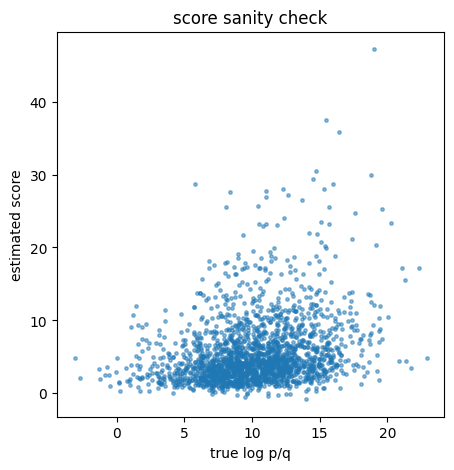

In [67]:
# compare learned score to exact log p(x)/q(x)
# for Gaussians:
# log p(x)/q(x) = const - 0.5 * x^T (Sigma^{-1} - I) x

block = np.array([[1.0, rho], [rho, 1.0]], dtype=np.float32)
n_blocks = num_dims // 2

Sigma = np.kron(np.eye(n_blocks, dtype=np.float32), block)
Sigma_inv = np.linalg.inv(Sigma)
logdet_Sigma = np.log(np.linalg.det(Sigma))

x = p_test[:2000].detach().cpu().numpy()

true_scores = (
    -0.5 * np.sum(x * (((Sigma_inv - np.eye(num_dims, dtype=np.float32)) @ x.T).T), axis=1)
    - 0.5 * logdet_Sigma
)

with torch.no_grad():
    Ws = 0.5 * (W + W.T)
    est_scores = (
        torch.einsum("bi,ij,bj->b", p_test[:2000], Ws, p_test[:2000]) + b
    ).cpu().numpy()

plt.figure(figsize=(5, 5))
plt.scatter(true_scores, est_scores, s=6, alpha=0.5)
plt.xlabel("true log p/q")
plt.ylabel("estimated score")
plt.title("score sanity check")
plt.show()
